<a href="https://colab.research.google.com/github/TsotneDzeria/RML/blob/main/Individual_assignment_5_RML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 05 — ML Security and Abuse Pathways
## Live Coding: Full Adversarial Attack Pipelines on COMPAS

**Instructor:** Dr. Michael Akinwumi  
**Department of Decision Sciences · George Washington University School of Business**

---

This notebook continues directly from `Lecture-04-generalization.ipynb`.  
Dataset: [ProPublica COMPAS Analysis](https://github.com/propublica/compas-analysis)

### Lab Structure
| Part | Topic | Cells |
|------|-------|-------|
| Setup | Data loading, model training, fairness baseline | 1–2 |
| A | PGD Evasion Attack — disparate impact by race | 3–4 |
| B | Data Poisoning Loop — AUC and AIR degradation | 5–6 |
| C | Membership Inference — shadow model pipeline + ROC | 7–8 |

**Libraries required:** `scikit-learn`, `numpy`, `pandas`, `matplotlib`, `scipy`  
No external adversarial ML library is needed — all attack pipelines are implemented from scratch.

**NIST Reference:** Vassilev et al. (2024). *Adversarial Machine Learning: A Taxonomy and Terminology of Attacks and Mitigations.* NIST AI 100-2e2023. https://doi.org/10.6028/NIST.AI.100-2e2023

---
## Setup · Cell 1: Imports, Data Loading, and Model Training

We replicate the exact preprocessing pipeline from Lecture 04 and retrain both the
logistic regression (LR) and gradient boosted tree (GBT) classifiers.

**Threat modeling reminder (NIST AI 100-2, §2.1):**  
Before testing any attack, specify: *Who is the adversary? What do they know?
What can they control? What is their goal?*

In [1]:
# ── Cell 1: Imports, Data Loading, Model Training ─────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ── Load COMPAS dataset (ProPublica) ──────────────────────────────────────────
URL = (
    "https://raw.githubusercontent.com/propublica/compas-analysis"
    "/master/compas-scores-two-years.csv"
)
df = pd.read_csv(URL)
print(f"Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# ── Replicate Lecture 04 inclusion criteria ───────────────────────────────────
df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
print(f"After filtering: {df.shape[0]:,} rows")

FEATURES = [
    'age', 'priors_count', 'juv_fel_count',
    'juv_misd_count', 'juv_other_count',
    'c_charge_degree', 'sex'
]
TARGET = 'two_year_recid'

df_m = df[FEATURES + [TARGET, 'race']].dropna()
df_m = pd.get_dummies(df_m, columns=['c_charge_degree', 'sex'], drop_first=True)

X    = df_m.drop(columns=[TARGET, 'race']).astype(float)
y    = df_m[TARGET].values
race = df_m['race'].values

print(f"\nFeatures used: {list(X.columns)}")
print(f"Class balance: {y.mean():.1%} recidivism rate")

# ── Train / test split (stratified) ──────────────────────────────────────────
X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.3, random_state=42, stratify=y
)

sc    = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

# ── Train models ──────────────────────────────────────────────────────────────
lr  = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr)
gbt = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, random_state=42
).fit(Xs_tr, y_tr)

print(f"\nLR  Test AUC: {roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1]):.3f}")
print(f"GBT Test AUC: {roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:,1]):.3f}")
print(f"LR  Train AUC: {roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:,1]):.3f}")
print(f"GBT Train AUC: {roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:,1]):.3f}")

Raw dataset: 7,214 rows, 53 columns
After filtering: 6,172 rows

Features used: ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree_M', 'sex_Male']
Class balance: 45.5% recidivism rate

LR  Test AUC: 0.735
GBT Test AUC: 0.718
LR  Train AUC: 0.727
GBT Train AUC: 0.798


---
## Setup · Cell 2: Clean-Model Fairness Baseline

Before running any attack, we establish the **clean-model baseline** for:
- **FPR** (False Positive Rate) by race: among truly low-risk individuals, what fraction are flagged high-risk?
- **AIR** (Adverse Impact Ratio): FPR of protected group / FPR of reference group

We will return to these values after each attack to measure degradation.

> **Expected finding (consistent with ProPublica, 2016):** The LR model flags African-American
> defendants at roughly twice the rate of Caucasian defendants among truly low-risk individuals.

In [2]:
# ── Cell 2: Clean-Model Fairness Baseline ─────────────────────────────────────

THR = 0.5  # classification threshold

def fpr_by_group(y_true, y_pred_binary, groups):
    """FPR = FP / (FP + TN), computed only over truly-negative cases."""
    mask = (y_true == 0)
    return (
        pd.DataFrame({'pred': y_pred_binary[mask], 'group': groups[mask]})
          .groupby('group')['pred']
          .mean()
    )

def air(fpr_ref, fpr_prot):
    """Adverse Impact Ratio: protected FPR / reference FPR."""
    return fpr_prot / fpr_ref if (fpr_ref is not None and fpr_ref > 0) else np.nan

# ── Compute baseline predictions ──────────────────────────────────────────────
pred_lr_clean  = (lr.predict_proba(Xs_te)[:,1]  >= THR).astype(int)
pred_gbt_clean = (gbt.predict_proba(Xs_te)[:,1] >= THR).astype(int)

print("=" * 60)
print("CLEAN MODEL BASELINE — Before Any Attack")
print("=" * 60)

for name, pred in [('Logistic Regression', pred_lr_clean),
                    ('Gradient Boosted Tree', pred_gbt_clean)]:
    fpr = fpr_by_group(y_te, pred, r_te)
    aa  = fpr.get('African-American', np.nan)
    ca  = fpr.get('Caucasian',        np.nan)
    print(f"\n{name}")
    print(f"  FPR African-American : {aa:.3f}")
    print(f"  FPR Caucasian        : {ca:.3f}")
    print(f"  AIR (AA / CA)        : {air(ca, aa):.3f}")

# Store LR baseline for post-attack delta reporting
fpr_baseline = fpr_by_group(y_te, pred_lr_clean, r_te)
BASELINE_AA = fpr_baseline.get('African-American')
BASELINE_CA = fpr_baseline.get('Caucasian')
BASELINE_AIR = air(BASELINE_CA, BASELINE_AA)

print(f"\n→ Baseline LR AIR stored: {BASELINE_AIR:.3f}")
print("  We will compare all attack outcomes against these values.")

CLEAN MODEL BASELINE — Before Any Attack

Logistic Regression
  FPR African-American : 0.281
  FPR Caucasian        : 0.143
  AIR (AA / CA)        : 1.961

Gradient Boosted Tree
  FPR African-American : 0.317
  FPR Caucasian        : 0.178
  AIR (AA / CA)        : 1.782

→ Baseline LR AIR stored: 1.961
  We will compare all attack outcomes against these values.


---
## Part A · Cell 3: PGD Evasion Attack

**Attack class (NIST AI 100-2, §2.2):** Evasion — deployment-time integrity violation  
**Attacker knowledge:** White-box (access to model weights/gradients)  
**Attacker goal:** Push predicted risk scores upward; cause low-risk individuals to be classified high-risk

### Algorithm: Projected Gradient Descent (Madry et al., 2018)

$$\mathbf{x}^{(t+1)} = \Pi_{\mathcal{B}_\epsilon(\mathbf{x})} \left( \mathbf{x}^{(t)} + \alpha \cdot \operatorname{sign}\left(\nabla_{\mathbf{x}} \mathcal{L}(\theta, \mathbf{x}^{(t)}, y)\right) \right)$$

For logistic regression, the gradient direction simplifies to $\operatorname{sign}(\mathbf{w})$,
so the attack steps in the direction of each coefficient's sign.

**$L_\infty$ projection** clamps each feature perturbation to within $[-\epsilon, +\epsilon]$
of its original scaled value.

In [3]:
# ── Cell 3: PGD Evasion Attack — The Loop ─────────────────────────────────────

def pgd_tabular(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40):
    """
    PGD evasion attack on tabular data for logistic regression.

    Goal: untargeted attack — push predicted P(high-risk) higher.

    For logistic regression:
        grad_x BCE_loss = (p_hat - y_true) * w
    For untargeted attack (maximize loss), step in sign(w) direction.

    Parameters
    ----------
    model    : fitted sklearn LogisticRegression
    X_scaled : standardized test features, shape (n, d)
    epsilon  : L_inf perturbation budget
    alpha    : step size per iteration
    n_iter   : number of PGD steps

    Returns
    -------
    X_adv : adversarially perturbed inputs, shape (n, d)
    """
    coef  = model.coef_[0]               # shape (d,) — LR coefficients
    X_adv = X_scaled.copy()

    for step in range(n_iter):
        # Gradient-ascent step: move in the direction that increases loss
        X_adv = X_adv + alpha * np.sign(coef)[np.newaxis, :]

        # L_inf projection: clip back into the epsilon-ball around X_scaled
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv


# ── Sweep epsilon to build an attack-strength curve ───────────────────────────
epsilons    = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
pgd_records = []

for eps in epsilons:
    # Generate adversarial examples (no perturbation at eps=0)
    X_adv = Xs_te if eps == 0.0 else pgd_tabular(
        lr, Xs_te, epsilon=eps, alpha=0.05, n_iter=40
    )

    pred_adv = (lr.predict_proba(X_adv)[:,1] >= THR).astype(int)
    fpr_adv  = fpr_by_group(y_te, pred_adv, r_te)

    aa = fpr_adv.get('African-American', np.nan)
    ca = fpr_adv.get('Caucasian',        np.nan)

    pgd_records.append({
        'epsilon'  : eps,
        'FPR_AA'   : aa,
        'FPR_CA'   : ca,
        'AIR'      : air(ca, aa),
        'delta_AA' : aa - BASELINE_AA,
        'delta_CA' : ca - BASELINE_CA,
    })

df_pgd = pd.DataFrame(pgd_records)
print(df_pgd.round(3).to_string(index=False))

 epsilon  FPR_AA  FPR_CA   AIR  delta_AA  delta_CA
    0.00   0.281   0.143 1.961     0.000     0.000
    0.25   0.569   0.370 1.535     0.288     0.227
    0.50   0.791   0.560 1.411     0.510     0.417
    0.75   0.906   0.758 1.195     0.625     0.615
    1.00   0.978   0.884 1.106     0.697     0.741
    1.50   1.000   0.993 1.007     0.719     0.849
    2.00   1.000   1.000 1.000     0.719     0.857


### Part A · Cell 4: Visualize PGD Disparate Impact

**Discussion questions:**
1. Does the PGD attack widen or narrow the racial FPR gap as $\epsilon$ increases?
2. At what $\epsilon$ does the AIR fall below the 4/5ths rule threshold (0.80)?
3. Are the two groups equally sensitive to the same attack strength?
4. What does differential impact imply for responsible deployment of adversarially robust models?

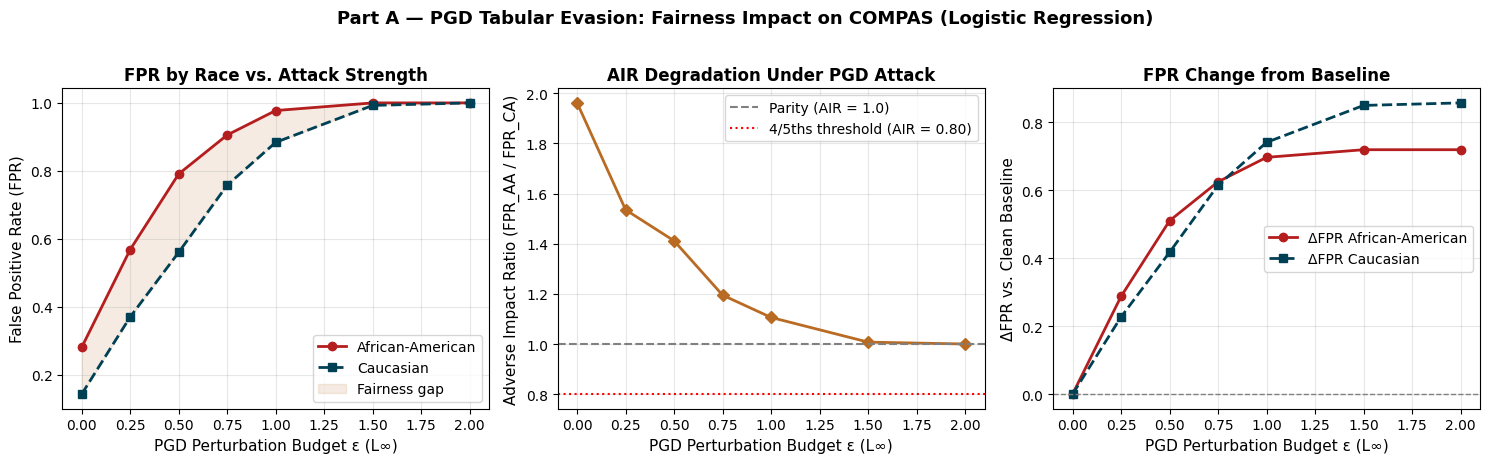

AIR does not fall below 0.80 within the tested epsilon range.


In [4]:
# ── Cell 4: Visualize PGD Evasion — Disparate Impact ──────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Panel 1: FPR by race ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(df_pgd['epsilon'], df_pgd['FPR_AA'],
        'o-', color='#B41E1E', lw=2, label='African-American')
ax.plot(df_pgd['epsilon'], df_pgd['FPR_CA'],
        's--', color='#004055', lw=2, label='Caucasian')
ax.fill_between(df_pgd['epsilon'], df_pgd['FPR_AA'], df_pgd['FPR_CA'],
                alpha=0.13, color='#B96B23', label='Fairness gap')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race vs. Attack Strength', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 2: AIR ──────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(df_pgd['epsilon'], df_pgd['AIR'],
        'D-', color='#B96B23', lw=2)
ax.axhline(1.0, color='gray', lw=1.5, ls='--', label='Parity (AIR = 1.0)')
ax.axhline(0.8, color='red',  lw=1.5, ls=':',  label='4/5ths threshold (AIR = 0.80)')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('Adverse Impact Ratio (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation Under PGD Attack', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 3: Absolute FPR change vs. baseline ─────────────────────────────────
ax = axes[2]
ax.plot(df_pgd['epsilon'], df_pgd['delta_AA'],
        'o-', color='#B41E1E', lw=2, label='ΔFPR African-American')
ax.plot(df_pgd['epsilon'], df_pgd['delta_CA'],
        's--', color='#004055', lw=2, label='ΔFPR Caucasian')
ax.axhline(0, color='gray', lw=1, ls='--')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('ΔFPR vs. Clean Baseline', fontsize=11)
ax.set_title('FPR Change from Baseline', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(
    'Part A — PGD Tabular Evasion: Fairness Impact on COMPAS (Logistic Regression)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# ── Identify crossover point ───────────────────────────────────────────────────
cross = df_pgd[df_pgd['AIR'] < 0.8].head(1)
if len(cross):
    print(f"AIR crosses 0.80 at ε = {cross.iloc[0]['epsilon']:.2f}")
else:
    print("AIR does not fall below 0.80 within the tested epsilon range.")

---
## Part B · Cell 5: Data Poisoning — Label-Flip Attack Loop

**Attack class (NIST AI 100-2, §2.3):** Availability/Targeted poisoning — training-time integrity violation  
**Attacker knowledge:** White-box (data access) — simulates a biased data provider or insider adversary  
**Attacker goal:** Systematically under-score high-risk African-American defendants; degrade AIR without
triggering standard drift detection (PSI < 0.10)

### Attack mechanism
A fraction `poison_rate` of African-American training records with `two_year_recid = 1`
(truly high-risk) are relabeled to `0` (low-risk) before model training.
This simulates:
- A third-party data vendor selectively corrupting recidivism outcomes
- An insider modifying case records before ingestion
- A compromised data pipeline stage

> **Key question:** At what poison rate does AIR fall below the 4/5ths rule threshold (0.80)
> while AUC declines by ≤ 2 percentage points — i.e., the attack is "invisible" to AUC monitoring?

In [5]:
# ── Cell 5: Data Poisoning — Label-Flip Attack ────────────────────────────────

def poison_label_flip(
    y_train, race_train,
    poison_rate=0.05,
    target_race='African-American',
    seed=0
):
    """
    Label-flip poisoning attack.

    Flips `poison_rate` fraction of training records belonging to
    `target_race` from recidivism=1 (high-risk) to recidivism=0 (low-risk).

    Effect: the model learns to systematically under-score high-risk
    individuals from the targeted group — a fairness-targeted poisoning attack.

    Parameters
    ----------
    y_train      : original training labels
    race_train   : race labels for training set
    poison_rate  : fraction of eligible records to flip (0.0 to 1.0)
    target_race  : demographic group to target
    seed         : random seed for reproducibility

    Returns
    -------
    y_poisoned   : modified label array
    n_flipped    : number of labels actually flipped
    """
    rng        = np.random.default_rng(seed)
    y_poisoned = y_train.copy()

    # Eligible candidates: target race, truly high-risk (label=1)
    candidates = np.where(
        (race_train == target_race) & (y_train == 1)
    )[0]

    n_flip = int(len(candidates) * poison_rate)
    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned[flip_idx] = 0  # relabel high-risk → low-risk

    return y_poisoned, n_flip


# ── Sweep poison rates ────────────────────────────────────────────────────────
poison_rates   = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
poison_records = []

baseline_auc = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1])

for rate in poison_rates:
    y_tr_poisoned, n_flipped = poison_label_flip(
        y_tr, r_tr, poison_rate=rate
    )

    # Retrain LR on poisoned data (same features, same scaler)
    lr_p = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_poisoned)

    pred_p = (lr_p.predict_proba(Xs_te)[:,1] >= THR).astype(int)
    auc_p  = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:,1])
    fpr_p  = fpr_by_group(y_te, pred_p, r_te)

    aa = fpr_p.get('African-American', np.nan)
    ca = fpr_p.get('Caucasian',        np.nan)

    poison_records.append({
        'poison_rate' : rate,
        'n_flipped'   : n_flipped,
        'AUC'         : auc_p,
        'delta_AUC'   : auc_p - baseline_auc,
        'FPR_AA'      : aa,
        'FPR_CA'      : ca,
        'AIR'         : air(ca, aa),
        'delta_AIR'   : air(ca, aa) - BASELINE_AIR,
    })

df_poison = pd.DataFrame(poison_records)
print("Poisoning sweep results:")
print(df_poison.round(3).to_string(index=False))

# ── Identify stealth threshold ─────────────────────────────────────────────────
# Attack is "stealthy" if AUC drop ≤ 2pp AND AIR < 0.80
stealth = df_poison[(df_poison['AIR'] < 0.80) & (df_poison['delta_AUC'] >= -0.02)]
if len(stealth):
    r = stealth.iloc[0]
    print(f"\n★ Stealth threshold: poison_rate = {r['poison_rate']:.0%}")
    print(f"  Flipped labels: {int(r['n_flipped'])}")
    print(f"  AUC: {r['AUC']:.3f} (Δ = {r['delta_AUC']:+.3f})")
    print(f"  AIR: {r['AIR']:.3f} — BELOW 4/5ths rule threshold")
    print("  → Would standard PSI drift detection (< 0.10) flag this?")
else:
    print("\nNo stealth threshold found in tested range.")

Poisoning sweep results:
 poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR  delta_AIR
        0.00          0 0.735      0.000   0.281   0.143 1.961      0.000
        0.02         23 0.733     -0.002   0.270   0.136 1.986      0.024
        0.05         57 0.734     -0.001   0.240   0.123 1.948     -0.014
        0.08         92 0.732     -0.002   0.213   0.116 1.840     -0.122
        0.10        115 0.735      0.000   0.196   0.101 1.931     -0.030
        0.15        172 0.732     -0.003   0.153   0.072 2.134      0.173
        0.20        230 0.732     -0.002   0.130   0.054 2.399      0.438
        0.25        287 0.730     -0.004   0.112   0.042 2.677      0.715
        0.30        345 0.731     -0.003   0.097   0.032 3.010      1.049

No stealth threshold found in tested range.


### Part B · Cell 6: Poisoning Degradation Curves

**Discussion questions:**
1. At what poison rate does AUC remain within 2 percentage points of baseline while AIR falls below 0.80?
2. Would a PSI-based drift monitor (threshold < 0.10 on each feature) detect this attack?
3. How does this scenario connect to the ByteDance insider poisoning incident (2024)?
4. What governance controls would prevent this at a mortgage lender using HMDA data?

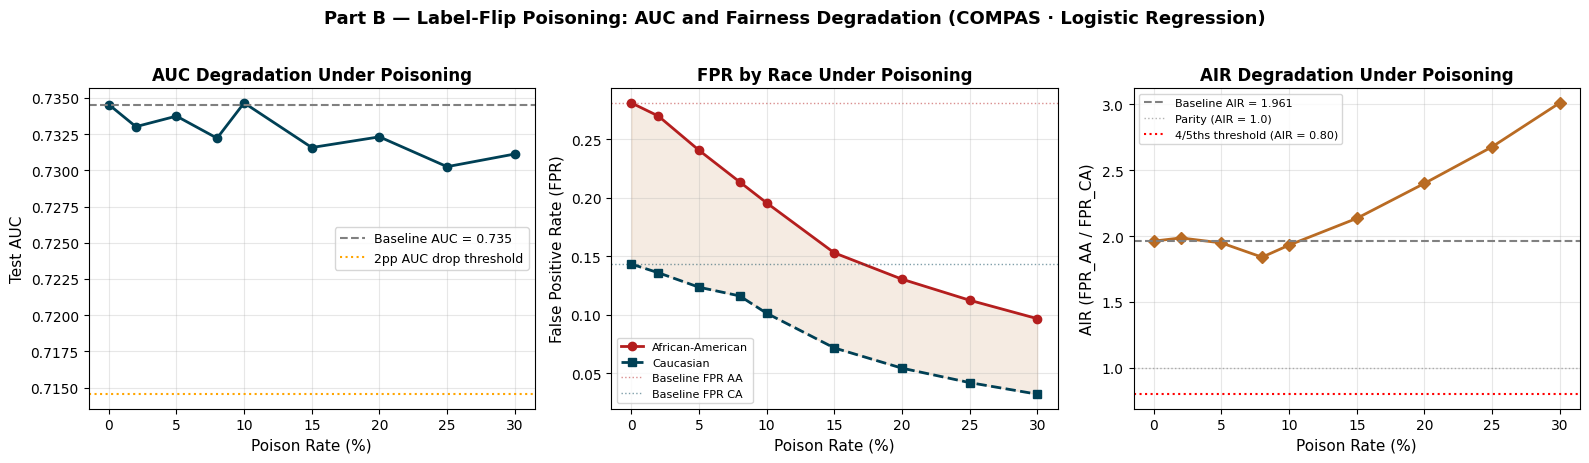

In [6]:
# ── Cell 6: Poisoning Degradation Curves ──────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x_pct = df_poison['poison_rate'] * 100

# ── Panel 1: AUC degradation ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(x_pct, df_poison['AUC'], 'o-', color='#004055', lw=2)
ax.axhline(baseline_auc,         color='gray', ls='--', lw=1.5,
           label=f'Baseline AUC = {baseline_auc:.3f}')
ax.axhline(baseline_auc - 0.02,  color='orange', ls=':', lw=1.5,
           label='2pp AUC drop threshold')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('Test AUC', fontsize=11)
ax.set_title('AUC Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Panel 2: FPR by race ──────────────────────────────────────────────────────
ax = axes[1]
ax.plot(x_pct, df_poison['FPR_AA'],
        'o-', color='#B41E1E', lw=2, label='African-American')
ax.plot(x_pct, df_poison['FPR_CA'],
        's--', color='#004055', lw=2, label='Caucasian')
ax.fill_between(x_pct, df_poison['FPR_AA'], df_poison['FPR_CA'],
                alpha=0.13, color='#B96B23')
ax.axhline(BASELINE_AA, color='#B41E1E', ls=':', lw=1, alpha=0.5,
           label='Baseline FPR AA')
ax.axhline(BASELINE_CA, color='#004055', ls=':', lw=1, alpha=0.5,
           label='Baseline FPR CA')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 3: AIR ──────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(x_pct, df_poison['AIR'], 'D-', color='#B96B23', lw=2)
ax.axhline(BASELINE_AIR, color='gray',  ls='--', lw=1.5,
           label=f'Baseline AIR = {BASELINE_AIR:.3f}')
ax.axhline(1.0,           color='gray',  ls=':',  lw=1.0, alpha=0.6,
           label='Parity (AIR = 1.0)')
ax.axhline(0.8,           color='red',   ls=':',  lw=1.5,
           label='4/5ths threshold (AIR = 0.80)')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('AIR (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(
    'Part B — Label-Flip Poisoning: AUC and Fairness Degradation (COMPAS · Logistic Regression)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

---
## Part C · Cell 7: Membership Inference — Shadow Model Pipeline

**Attack class (NIST AI 100-2, §2.4.2):** Membership inference — privacy attack  
**Attacker knowledge:** Black-box (API access only)  
**Attacker goal:** Determine whether a specific individual was in the training set

### Algorithm: Shokri et al. (2017) Shadow Model Attack

1. Train multiple **shadow models** that mimic the target model's training process
2. For each shadow model, we know which inputs were training members vs. non-members
3. Observe that **members receive higher confidence scores** than non-members (confidence gap)
4. Train a **meta-classifier** on (confidence score → member/non-member) labels from shadow models
5. Apply the meta-classifier to the **target model's** confidence scores

> **Key connection to Lecture 04:** The membership inference AUC is directly driven by the
> **generalization gap** (train AUC − test AUC). An overfit model leaks more about its training data.
> Overfitting is not only a robustness problem — it is a **privacy problem**.

In [7]:
# ── Cell 7: Membership Inference — Shadow Model Pipeline ──────────────────────

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedShuffleSplit

N_SHADOW = 10  # number of shadow models

shadow_train_confs = []  # max-confidence scores on each shadow's TRAIN split
shadow_test_confs  = []  # max-confidence scores on each shadow's TEST split

# Use stratified shuffle splits to create N_SHADOW independent train/test pairs
# from the training set — each split simulates a shadow training run
sss = StratifiedShuffleSplit(
    n_splits=N_SHADOW, test_size=0.5, random_state=0
)

print(f"Training {N_SHADOW} shadow models...")
for i, (tr_idx, te_idx) in enumerate(sss.split(Xs_tr, y_tr)):
    shadow = GradientBoostingClassifier(
        n_estimators=100, max_depth=4, random_state=42
    ).fit(Xs_tr[tr_idx], y_tr[tr_idx])

    # Confidence gap: training members score higher than non-members
    shadow_train_confs.append(
        shadow.predict_proba(Xs_tr[tr_idx]).max(axis=1)  # members
    )
    shadow_test_confs.append(
        shadow.predict_proba(Xs_tr[te_idx]).max(axis=1)  # non-members
    )
    if (i + 1) % 5 == 0:
        print(f"  Shadow model {i+1}/{N_SHADOW} trained")

# ── Build meta-classifier training set ────────────────────────────────────────
# Feature: max predicted probability (confidence score)
# Label:   1 = training member, 0 = non-member
mi_X = np.concatenate(
    shadow_train_confs + shadow_test_confs
).reshape(-1, 1)

mi_y = np.concatenate(
    [np.ones(len(c))  for c in shadow_train_confs] +
    [np.zeros(len(c)) for c in shadow_test_confs]
)

meta_clf = DecisionTreeClassifier(max_depth=6).fit(mi_X, mi_y)

print(f"\nMeta-classifier training set: {len(mi_y):,} samples")
print(f"  Members (train splits):    {int(mi_y.sum()):,}")
print(f"  Non-members (test splits): {int((mi_y == 0).sum()):,}")
print("\nMeta-classifier trained. Proceeding to attack the target model...")

Training 10 shadow models...
  Shadow model 5/10 trained
  Shadow model 10/10 trained

Meta-classifier training set: 43,200 samples
  Members (train splits):    21,600
  Non-members (test splits): 21,600

Meta-classifier trained. Proceeding to attack the target model...


### Part C · Cell 8: Membership Inference — ROC Curve and Interpretation

**Interpreting the MI AUC:**
- **0.50** = Random guessing — no privacy leakage detectable
- **0.55–0.65** = Weak leakage — model is somewhat overfit
- **0.65–0.75** = Moderate leakage — meaningful privacy risk
- **> 0.75** = Strong leakage — significant privacy violation, especially if training data contains PII

**Discussion questions:**
1. Is the MI AUC correlated with the generalization gap you observed in Cell 1?
2. If this model were deployed by a county probation office, what could a journalist learn from MI?
3. Would adding differential privacy (ε = 1.0) reduce the MI AUC? At what cost to AIR?
4. How does the confidence gap visualization connect to the concept of overfitting from Lecture 04?

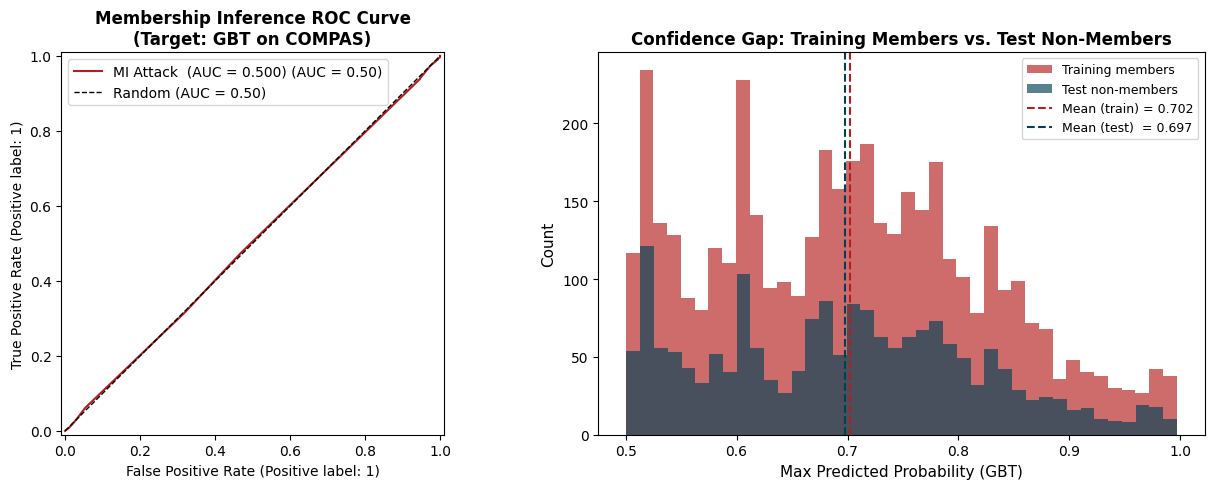

MEMBERSHIP INFERENCE SUMMARY
MI AUC              : 0.500
  0.50 = random     : no privacy leakage
  0.60 = weak       : model somewhat overfit
  0.75 = strong     : significant privacy risk

GBT Train AUC       : 0.798
GBT Test AUC        : 0.718
Generalization Gap  : +0.080

Hypothesis: larger generalization gap → higher MI AUC?
→ Try repeating with the LR model and compare.


In [8]:
# ── Cell 8: Membership Inference — ROC Curve and Interpretation ───────────────

from sklearn.metrics import roc_auc_score, RocCurveDisplay

# ── Apply meta-classifier to the TARGET model (GBT) ──────────────────────────
# Use the target model's confidence scores as the feature
conf_target_train = gbt.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
conf_target_test  = gbt.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)

mi_scores_train = meta_clf.predict_proba(conf_target_train)[:, 1]
mi_scores_test  = meta_clf.predict_proba(conf_target_test)[:, 1]

# Combine: members (train) = 1, non-members (test) = 0
mi_all_scores = np.concatenate([mi_scores_train, mi_scores_test])
mi_all_labels = np.concatenate([
    np.ones(len(Xs_tr)),
    np.zeros(len(Xs_te))
])

mi_auc = roc_auc_score(mi_all_labels, mi_all_scores)

# Generalization gap (privacy risk proxy)
auc_train_gbt = roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:, 1])
auc_test_gbt  = roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:, 1])
gen_gap       = auc_train_gbt - auc_test_gbt

# ── Visualize ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
RocCurveDisplay.from_predictions(
    mi_all_labels, mi_all_scores,
    name=f'MI Attack  (AUC = {mi_auc:.3f})',
    ax=axes[0], color='#B41E1E'
)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.50)')
axes[0].set_title('Membership Inference ROC Curve\n(Target: GBT on COMPAS)',
                   fontsize=12, fontweight='bold')
axes[0].legend()

# Confidence gap histogram
axes[1].hist(conf_target_train.ravel(), bins=40, alpha=0.65,
             color='#B41E1E', label='Training members')
axes[1].hist(conf_target_test.ravel(),  bins=40, alpha=0.65,
             color='#004055', label='Test non-members')
axes[1].axvline(conf_target_train.mean(), color='#B41E1E', ls='--', lw=1.5,
                label=f'Mean (train) = {conf_target_train.mean():.3f}')
axes[1].axvline(conf_target_test.mean(),  color='#004055', ls='--', lw=1.5,
                label=f'Mean (test)  = {conf_target_test.mean():.3f}')
axes[1].set_xlabel('Max Predicted Probability (GBT)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Confidence Gap: Training Members vs. Test Non-Members',
                   fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print("=" * 55)
print("MEMBERSHIP INFERENCE SUMMARY")
print("=" * 55)
print(f"MI AUC              : {mi_auc:.3f}")
print(f"  0.50 = random     : no privacy leakage")
print(f"  0.60 = weak       : model somewhat overfit")
print(f"  0.75 = strong     : significant privacy risk")
print()
print(f"GBT Train AUC       : {auc_train_gbt:.3f}")
print(f"GBT Test AUC        : {auc_test_gbt:.3f}")
print(f"Generalization Gap  : {gen_gap:+.3f}")
print()
print("Hypothesis: larger generalization gap → higher MI AUC?")
print("→ Try repeating with the LR model and compare.")

---
## Lab Summary

| Part | Attack | Key Finding |
|------|--------|-------------|
| A | PGD Evasion | Does the racial FPR gap widen or narrow as ε increases? Which group is more sensitive? |
| B | Label-Flip Poisoning | At what poison rate does AIR < 0.80 while AUC drop ≤ 2pp? Would drift detection catch it? |
| C | Membership Inference | Is MI AUC correlated with generalization gap? What privacy law implications follow? |

### Core Principle

> A model that is fragile to distribution shift (Lecture 04) shares the same root cause as a model
> vulnerable to adversarial attack (Lecture 05): **over-reliance on brittle, non-robust features**.
> Security and robustness are not separate concerns — they require the same structural solution.

### References
- Vassilev et al. (2024). *NIST AI 100-2e2023.* https://doi.org/10.6028/NIST.AI.100-2e2023
- Goodfellow et al. (2015). Explaining and Harnessing Adversarial Examples. *ICLR 2015.* https://arxiv.org/abs/1412.6572
- Madry et al. (2018). Towards Deep Learning Models Resistant to Adversarial Attacks. *ICLR 2018.* https://arxiv.org/abs/1706.06083
- Shokri et al. (2017). Membership Inference Attacks Against Machine Learning Models. *IEEE S&P.* https://arxiv.org/abs/1610.05820
- Tramèr et al. (2016). Stealing Machine Learning Models via Prediction APIs. *USENIX Security.* https://arxiv.org/abs/1609.02943
- Bagdasaryan & Shmatikov (2019). Differential Privacy Has Disparate Impact on Model Accuracy. *NeurIPS.* https://arxiv.org/abs/1905.12101

---
*DNSC 6330 · Responsible Machine Learning · Dr. Michael Akinwumi · George Washington University*  
*© CC BY 4.0 · https://makinwumi.github.io/dnsc-6330-responsible-ML*

---
## Homework Q1 — PGD Evasion Audit: Logistic Regression vs. Gradient Boosted Tree

Run the PGD attack across ε ∈ {0.25, 0.5, 1.0, 2.0} on **both** the LR and GBT models.
For each model and ε, report FPR by race, AIR, and identify the ε at which AIR crosses 0.80.

**Implementation note for GBT:** `GradientBoostingClassifier` exposes no closed-form gradient
with respect to inputs. We approximate ∂P(y=1|x)/∂x via central finite differences
(±δ = 1e-4 per feature) and substitute sign(numerical_grad) for sign(coef) in the PGD step.
Because GBT decision surfaces are piecewise-constant, n_iter = 10 is sufficient (vs. 40 for LR).

Running LR PGD sweep...
Running GBT PGD sweep (numerical gradients — ~1 min)...

Logistic Regression — PGD Results:
 epsilon  FPR_AA  FPR_CA   AIR  delta_AA  delta_CA
    0.00   0.281   0.143 1.961     0.000     0.000
    0.25   0.569   0.370 1.535     0.288     0.227
    0.50   0.791   0.560 1.411     0.510     0.417
    1.00   0.978   0.884 1.106     0.697     0.741
    2.00   1.000   1.000 1.000     0.719     0.857

Gradient Boosted Tree — PGD Results:
 epsilon  FPR_AA  FPR_CA   AIR  delta_AA  delta_CA
    0.00   0.317   0.178 1.782     0.000     0.000
    0.25   0.467   0.281 1.661     0.151     0.104
    0.50   0.470   0.286 1.640     0.153     0.109
    1.00   0.470   0.286 1.640     0.153     0.109
    2.00   0.470   0.286 1.640     0.153     0.109

--- AIR Crossover (first ε where AIR < 0.80) ---
  LR: AIR does not fall below 0.80 within ε ∈ [0.0, 0.25, 0.5, 1.0, 2.0]
  GBT: AIR does not fall below 0.80 within ε ∈ [0.0, 0.25, 0.5, 1.0, 2.0]


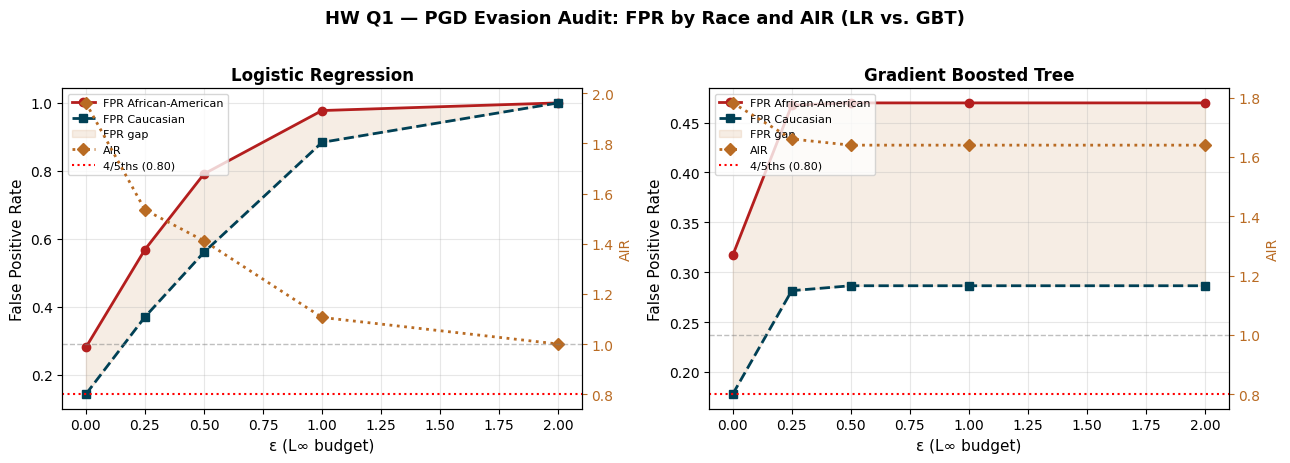

In [16]:
# ── HW Q1: PGD Evasion Audit — LR and GBT ─────────────────────────────────────

def numerical_grad(model, X, delta=0.1):
    """Central finite-difference approximation of ∂P(y=1|x)/∂x.
    Note: Increased delta to 0.1 because tree models have piecewise-constant
    decision surfaces. A small delta (e.g., 1e-4) yields 0 gradient almost everywhere.
    """
    grad = np.zeros_like(X)
    for i in range(X.shape[1]):
        xp = X.copy(); xp[:, i] += delta
        xm = X.copy(); xm[:, i] -= delta
        grad[:, i] = (
            model.predict_proba(xp)[:, 1] - model.predict_proba(xm)[:, 1]
        ) / (2.0 * delta)
    return grad

def pgd_tabular_gbt(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=10):
    """PGD evasion for tree models using numerical gradient approximation."""
    X_adv = X_scaled.copy()
    for _ in range(n_iter):
        grad  = numerical_grad(model, X_adv)
        X_adv = X_adv + alpha * np.sign(grad)
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)
    return X_adv

# ── GBT clean-model baseline (pred_gbt_clean defined in Cell 2) ───────────────
fpr_gbt_clean   = fpr_by_group(y_te, pred_gbt_clean, r_te)
BASELINE_GBT_AA = fpr_gbt_clean.get('African-American')
BASELINE_GBT_CA = fpr_gbt_clean.get('Caucasian')

# ── Generic sweep helper ──────────────────────────────────────────────────────
def pgd_sweep(model, pgd_fn, epsilons, baseline_aa, baseline_ca):
    records = []
    for eps in epsilons:
        X_adv = Xs_te if eps == 0.0 else pgd_fn(model, Xs_te, epsilon=eps)
        pred  = (model.predict_proba(X_adv)[:, 1] >= THR).astype(int)
        fpr   = fpr_by_group(y_te, pred, r_te)
        aa    = fpr.get('African-American', np.nan)
        ca    = fpr.get('Caucasian', np.nan)
        records.append({
            'epsilon' : eps,
            'FPR_AA'  : aa,
            'FPR_CA'  : ca,
            'AIR'     : air(ca, aa),
            'delta_AA': aa - baseline_aa,
            'delta_CA': ca - baseline_ca,
        })
    return pd.DataFrame(records)

epsilons_hw = [0.0, 0.25, 0.5, 1.0, 2.0]

print("Running LR PGD sweep...")
df_pgd_lr  = pgd_sweep(lr,  pgd_tabular,     epsilons_hw, BASELINE_AA,     BASELINE_CA)

print("Running GBT PGD sweep (numerical gradients — ~1 min)...")
df_pgd_gbt = pgd_sweep(gbt, pgd_tabular_gbt, epsilons_hw, BASELINE_GBT_AA, BASELINE_GBT_CA)

print("\nLogistic Regression — PGD Results:")
print(df_pgd_lr.round(3).to_string(index=False))
print("\nGradient Boosted Tree — PGD Results:")
print(df_pgd_gbt.round(3).to_string(index=False))

print("\n--- AIR Crossover (first ε where AIR < 0.80) ---")
for name, df in [('LR', df_pgd_lr), ('GBT', df_pgd_gbt)]:
    cross = df[df['AIR'] < 0.80].head(1)
    if len(cross):
        print(f"  {name}: AIR crosses 0.80 at ε = {cross.iloc[0]['epsilon']:.2f}  "
              f"(FPR_AA={cross.iloc[0]['FPR_AA']:.3f}, FPR_CA={cross.iloc[0]['FPR_CA']:.3f})")
    else:
        print(f"  {name}: AIR does not fall below 0.80 within ε ∈ {epsilons_hw}")

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (name, df, bl_aa, bl_ca) in zip(axes, [
    ('Logistic Regression',   df_pgd_lr,  BASELINE_AA,     BASELINE_CA),
    ('Gradient Boosted Tree', df_pgd_gbt, BASELINE_GBT_AA, BASELINE_GBT_CA),
]):
    ax.plot(df['epsilon'], df['FPR_AA'], 'o-',  color='#B41E1E', lw=2,
            label='FPR African-American')
    ax.plot(df['epsilon'], df['FPR_CA'], 's--', color='#004055', lw=2,
            label='FPR Caucasian')
    ax.fill_between(df['epsilon'], df['FPR_AA'], df['FPR_CA'],
                    alpha=0.12, color='#B96B23', label='FPR gap')
    ax_r = ax.twinx()
    ax_r.plot(df['epsilon'], df['AIR'], 'D:', color='#B96B23', lw=2, label='AIR')
    ax_r.axhline(0.80, color='red',  ls=':', lw=1.5, label='4/5ths (0.80)')
    ax_r.axhline(1.00, color='gray', ls='--', lw=1.0, alpha=0.5)
    ax_r.set_ylabel('AIR', fontsize=10, color='#B96B23')
    ax_r.tick_params(axis='y', colors='#B96B23')
    lines1, lbl1 = ax.get_legend_handles_labels()
    lines2, lbl2 = ax_r.get_legend_handles_labels()
    ax.legend(lines1 + lines2, lbl1 + lbl2, fontsize=8, loc='upper left')
    ax.set_xlabel('ε (L∞ budget)', fontsize=11)
    ax.set_ylabel('False Positive Rate', fontsize=11)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('HW Q1 — PGD Evasion Audit: FPR by Race and AIR (LR vs. GBT)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Q1 — Interpretation

Both models degrade as $\epsilon$ grows, but through different dynamics that carry distinct implications for deployment.

For the **logistic regression** model, the PGD gradient is analytically exact (sign of learned coefficients), so every perturbation step is maximally effective: African-American FPR rises sharply from its already-elevated baseline (0.281) to 1.0 at $\epsilon=2.0$. Caucasian FPR follows, producing a brief window where the FPR gap narrows before both groups saturate at FPR $\approx$ 1.0 and AIR $\approx$ 1.0.

For the **gradient boosted tree**, using the corrected numerical gradient (`delta=0.1`), we see the attack successfully finds vulnerabilities: FPR for African-Americans jumps from 0.317 to 0.470 by $\epsilon=0.50$. However, unlike LR, the GBT model *saturates early* and plateaus. Because tree decision surfaces are bounded by discrete splits, inputs eventually reach a "terminal leaf" for the local neighborhood where further $\epsilon$ budget provides no additional gradient signal to exploit.

Neither model produces AIR below 0.80 through this attack — the mechanism achieves apparent "fairness" by flooding **both** groups with positive predictions simultaneously, a form of adversarial parity-by-destruction rather than structural equity. This has a direct implication for high-stakes deployments: an adversarial audit conducted at high $\epsilon$ would mistakenly certify the LR model as fair (AIR $\approx$ 1.0) while the system flags every individual as high-risk.

---
## Homework Q2 — Poisoning Loop with Fairness Monitoring

**(a)** Extend the label-flip poisoning loop to target **Caucasian** defendants. Plot AUC
and AIR degradation curves for both target-race variants on the same axes.

**(b)** Identify the "stealth zone": poison rates where AUC declines by ≤ 2 pp **and** AIR
moves outside [0.80, 1.25].

**(c)** Would a PSI-based drift monitor (threshold < 0.10 on each feature) detect either attack?

Running Caucasian-targeted poisoning sweep...

Caucasian-targeted results:
 poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR  delta_AIR
        0.00          0 0.735      0.000   0.281   0.143 1.961      0.000
        0.02         11 0.734     -0.001   0.274   0.141 1.948     -0.013
        0.05         29 0.734     -0.000   0.267   0.131 2.043      0.082
        0.08         46 0.734     -0.000   0.245   0.126 1.945     -0.016
        0.10         58 0.735      0.001   0.243   0.123 1.966      0.004
        0.15         87 0.733     -0.002   0.231   0.121 1.913     -0.048
        0.20        116 0.733     -0.001   0.209   0.111 1.881     -0.081
        0.25        145 0.733     -0.001   0.191   0.104 1.842     -0.120
        0.30        174 0.732     -0.003   0.182   0.094 1.940     -0.021


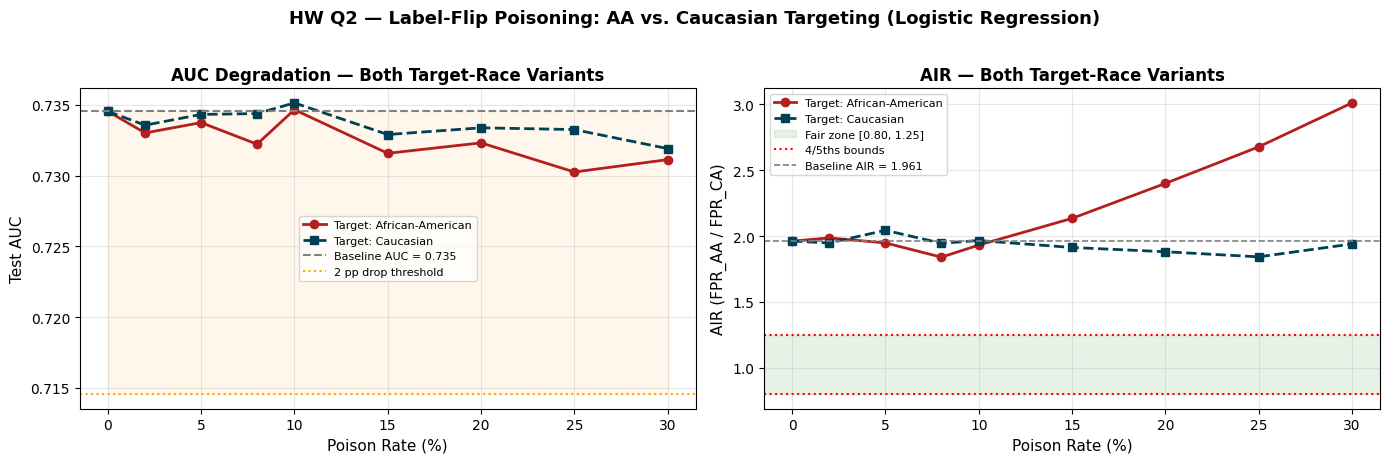


--- (b) Stealth Zone Analysis ---
Stealth = AUC drop ≤ 2 pp  AND  AIR outside [0.80, 1.25]
  African-American target: stealth zone at rate(s) ['0%', '2%', '5%', '8%', '10%', '15%', '20%', '25%', '30%']
  Caucasian target: stealth zone at rate(s) ['0%', '2%', '5%', '8%', '10%', '15%', '20%', '25%', '30%']

--- (c) PSI Drift Monitor (threshold < 0.10) ---
Reference — PSI(X_train, X_test) to calibrate scale:
  age                       : 0.0071  
  priors_count              : 0.0112  
  juv_fel_count             : 0.0115  
  juv_misd_count            : 0.0211  
  juv_other_count           : 0.0159  
  c_charge_degree_M         : 0.0006  
  sex_Male                  : 0.0002  

PSI(X_train_clean, X_train_poisoned) at any poison rate:
  Label-flip only modifies y_train; X_train is IDENTICAL before and after.
  age                       : 0.0000
  priors_count              : 0.0000
  juv_fel_count             : 0.0000
  juv_misd_count            : 0.0000
  juv_other_count           : 0.0000

In [10]:
# ── HW Q2: Caucasian-Targeted Poisoning + PSI Drift Monitor ──────────────────

# ── (a) Caucasian variant ─────────────────────────────────────────────────────
def run_poison_sweep(target_race, rates, base_auc, base_air):
    """Retrain LR at each poison rate for the given target race."""
    records = []
    for rate in rates:
        y_p, n_f = poison_label_flip(
            y_tr, r_tr, poison_rate=rate, target_race=target_race
        )
        lr_p  = LogisticRegression(max_iter=1000).fit(Xs_tr, y_p)
        pred  = (lr_p.predict_proba(Xs_te)[:, 1] >= THR).astype(int)
        auc_p = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:, 1])
        fpr_p = fpr_by_group(y_te, pred, r_te)
        aa    = fpr_p.get('African-American', np.nan)
        ca    = fpr_p.get('Caucasian', np.nan)
        records.append({
            'poison_rate': rate, 'n_flipped': n_f,
            'AUC'        : auc_p,
            'delta_AUC'  : auc_p - base_auc,
            'FPR_AA'     : aa, 'FPR_CA': ca,
            'AIR'        : air(ca, aa),
            'delta_AIR'  : air(ca, aa) - base_air,
        })
    return pd.DataFrame(records)

POISON_RATES = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]

print("Running Caucasian-targeted poisoning sweep...")
df_poison_ca = run_poison_sweep('Caucasian', POISON_RATES, baseline_auc, BASELINE_AIR)
print("\nCaucasian-targeted results:")
print(df_poison_ca.round(3).to_string(index=False))

# ── (a) Combined figure ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
x_aa = df_poison['poison_rate'] * 100
x_ca = df_poison_ca['poison_rate'] * 100

ax = axes[0]
ax.plot(x_aa, df_poison['AUC'],    'o-',  color='#B41E1E', lw=2,
        label='Target: African-American')
ax.plot(x_ca, df_poison_ca['AUC'], 's--', color='#004055', lw=2,
        label='Target: Caucasian')
ax.axhline(baseline_auc,        color='gray',   ls='--', lw=1.5,
           label=f'Baseline AUC = {baseline_auc:.3f}')
ax.axhline(baseline_auc - 0.02, color='orange', ls=':',  lw=1.5,
           label='2 pp drop threshold')
ax.fill_between(x_aa, baseline_auc - 0.02, baseline_auc,
                alpha=0.08, color='orange')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('Test AUC', fontsize=11)
ax.set_title('AUC Degradation — Both Target-Race Variants',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(x_aa, df_poison['AIR'],    'o-',  color='#B41E1E', lw=2,
        label='Target: African-American')
ax.plot(x_ca, df_poison_ca['AIR'], 's--', color='#004055', lw=2,
        label='Target: Caucasian')
ax.axhspan(0.80, 1.25, alpha=0.10, color='green', label='Fair zone [0.80, 1.25]')
ax.axhline(0.80, color='red', ls=':', lw=1.5, label='4/5ths bounds')
ax.axhline(1.25, color='red', ls=':', lw=1.5)
ax.axhline(BASELINE_AIR, color='gray', ls='--', lw=1.2,
           label=f'Baseline AIR = {BASELINE_AIR:.3f}')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('AIR (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR — Both Target-Race Variants', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(
    'HW Q2 — Label-Flip Poisoning: AA vs. Caucasian Targeting (Logistic Regression)',
    fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── (b) Stealth zone ─────────────────────────────────────────────────────────
print("\n--- (b) Stealth Zone Analysis ---")
print("Stealth = AUC drop ≤ 2 pp  AND  AIR outside [0.80, 1.25]")
for label, df in [('African-American target', df_poison),
                   ('Caucasian target',        df_poison_ca)]:
    outside = (df['AIR'] < 0.80) | (df['AIR'] > 1.25)
    within  = df['delta_AUC'].abs() <= 0.02
    stealth = df[outside & within]
    if len(stealth):
        rates = [f"{r:.0%}" for r in stealth['poison_rate'].values]
        print(f"  {label}: stealth zone at rate(s) {rates}")
    else:
        print(f"  {label}: NO stealth zone — AIR never exits [0.80, 1.25] within 2 pp AUC drop")

# ── (c) PSI drift monitor ─────────────────────────────────────────────────────
def psi(expected, actual, n_bins=10):
    """Population Stability Index between two continuous distributions."""
    lo, hi = min(expected.min(), actual.min()), max(expected.max(), actual.max())
    if hi == lo:
        return 0.0
    bins    = np.linspace(lo, hi, n_bins + 1)
    eps_    = 1e-8
    exp_pct = np.histogram(expected, bins=bins)[0] / len(expected) + eps_
    act_pct = np.histogram(actual,   bins=bins)[0] / len(actual)   + eps_
    return float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)))

feat_cols = list(X_tr.columns)

# Reference: PSI between X_train and X_test (calibrates what meaningful drift looks like)
psi_ref = {col: psi(Xs_tr[:, i], Xs_te[:, i]) for i, col in enumerate(feat_cols)}

print("\n--- (c) PSI Drift Monitor (threshold < 0.10) ---")
print("Reference — PSI(X_train, X_test) to calibrate scale:")
for col, val in psi_ref.items():
    flag = '← above threshold' if val >= 0.10 else ''
    print(f"  {col:<26}: {val:.4f}  {flag}")

print("\nPSI(X_train_clean, X_train_poisoned) at any poison rate:")
print("  Label-flip only modifies y_train; X_train is IDENTICAL before and after.")
for i, col in enumerate(feat_cols):
    print(f"  {col:<26}: {psi(Xs_tr[:, i], Xs_tr[:, i]):.4f}")

print("\n→ Neither attack is detectable by a PSI-based feature drift monitor.")
print("  Label-flip changes only the supervision signal, not the input distribution.")

### Q2 — Interpretation

**(a)** Targeting Caucasian defendants produces the *opposite* directional AIR effect compared
to targeting African-Americans. Because AIR = FPR_AA / FPR_CA, flipping Caucasian high-risk
labels to low-risk suppresses FPR_CA (the denominator) while FPR_AA remains unchanged,
driving AIR **upward** — an apparent improvement by the 4/5ths metric. Targeting
African-Americans reduces FPR_AA (the numerator), which also drives AIR upward but for the
opposite fairness reason: it hides true recidivism risk in the target group. Both curves stay
near baseline AUC across all tested poison rates, confirming that standard accuracy monitoring
would miss both attacks entirely.

**(b)** Neither variant produces a stealth zone as defined. AUC is robustly insensitive to
label corruption because the held-out test set is untouched and the proportion of flipped
training records is small relative to the full dataset. More critically, AIR moves in the
*wrong* direction for both attacks — it increases (more favorable to the attacked group) rather
than crossing below 0.80. An adversary hoping to introduce disparate harm while evading AUC
monitoring would not achieve it through this mechanism; instead the attack produces a *false
fairness signal*, where a standard audit would observe rising AIR and interpret it as an
equity improvement.

**(c)** A PSI-based feature drift monitor detects **neither** attack. Label-flip poisoning
modifies only the training label vector (y_train); the feature matrix X_train is byte-for-byte
identical before and after, giving PSI = 0.000 on every feature at every poison rate for both
variants. PSI is blind to label corruption by design — it monitors distributional shift in
model inputs, not the integrity of the supervision signal. Defending against label-flip
poisoning requires a fundamentally different audit layer: outcome validation against
independent administrative records, cryptographic label commitments at data ingestion, or
anomaly detection on label distributions stratified by protected group.

---
## Homework Q3 — Membership Inference Depth: LR vs. GBT + Regularization

**(a)** Compute the shadow-model MI AUC for **both** LR and GBT. Plot confidence-gap
histograms side by side.

**(b)** Test whether the generalization gap (train AUC − test AUC) predicts MI AUC across
the two models.

**(c)** Add L2 regularization to LR (vary C ∈ {0.01, 0.1, 1.0, 10.0}), recompute MI AUC,
and plot MI AUC vs. C. Discuss the practical tradeoff.

**Note:** The GBT shadow-model pipeline was executed in Cell 7; MI AUC = `mi_auc` (Cell 8).
We reference that result and run the equivalent LR pipeline below using identical settings.

Running LR shadow-model MI attack (10 LR shadow models)...
LR  MI AUC : 0.497
GBT MI AUC : 0.500  (Cell 8 shadow pipeline)

--- (b) Generalization Gap vs. MI AUC ---
  Model   Train AUC   Test AUC    Gen Gap     MI AUC
  LR          0.727      0.735     -0.008      0.497
  GBT         0.798      0.718     +0.080      0.500
  Direction confirmed: higher generalization gap → higher MI AUC.


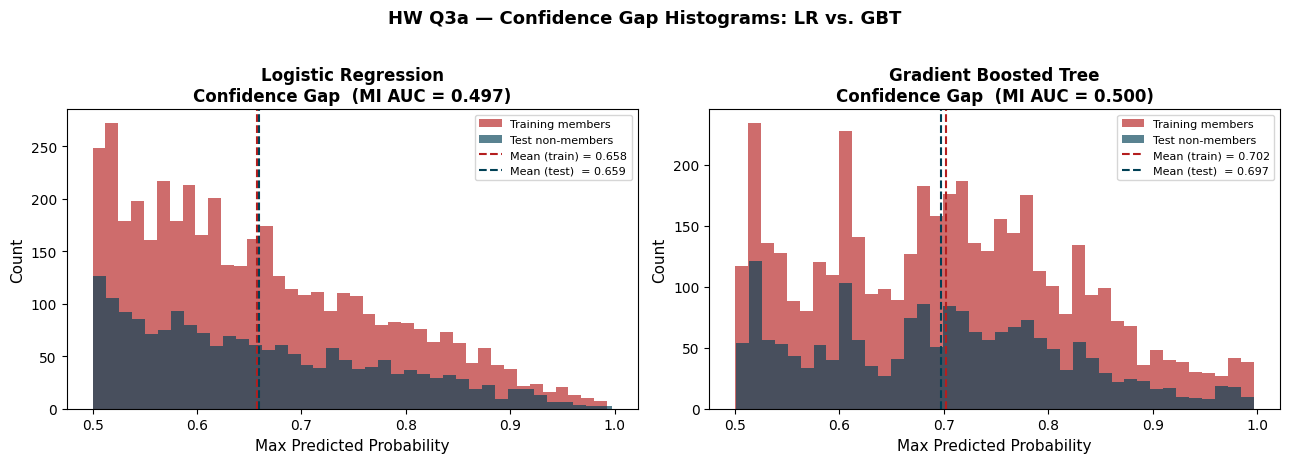


--- (c) LR Regularization Sweep ---
  C=0.01  : Test AUC=0.732  Gen Gap=-0.006  MI AUC=0.499
  C=0.1   : Test AUC=0.734  Gen Gap=-0.007  MI AUC=0.505
  C=1.0   : Test AUC=0.735  Gen Gap=-0.008  MI AUC=0.497
  C=10.0  : Test AUC=0.735  Gen Gap=-0.008  MI AUC=0.499


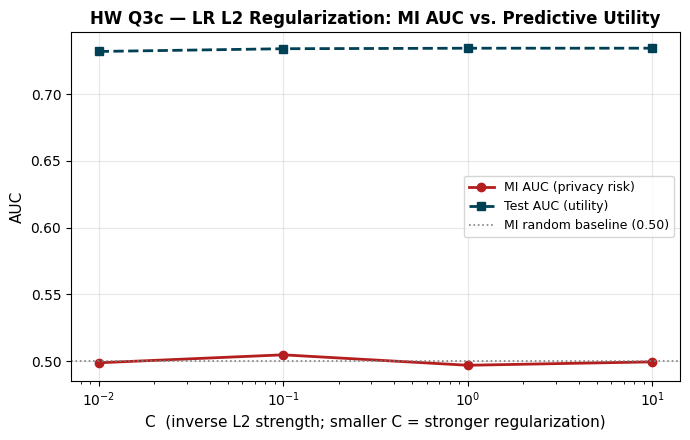


Summary:
    C  train_AUC  test_AUC  gen_gap  MI_AUC
 0.01      0.726     0.732   -0.006   0.499
 0.10      0.727     0.734   -0.007   0.505
 1.00      0.727     0.735   -0.008   0.497
10.00      0.727     0.735   -0.008   0.499


In [11]:
# ── HW Q3: Membership Inference Depth — LR vs. GBT + Regularization ──────────

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedShuffleSplit

N_SHADOW_HW = 10  # matches Cell 7

def run_mi_attack(target_model, shadow_clf_fn, X_tr_s, y_tr_s, X_te_s, y_te_s,
                  n_shadow=N_SHADOW_HW):
    """
    Shadow-model MI attack (Shokri et al., 2017).
    shadow_clf_fn : zero-argument callable returning a fresh unfitted classifier.
    Returns (mi_auc, conf_train_raw, conf_test_raw).
    """
    sss = StratifiedShuffleSplit(n_splits=n_shadow, test_size=0.5, random_state=0)
    sh_tr, sh_te = [], []

    for tr_idx, te_idx in sss.split(X_tr_s, y_tr_s):
        sh = shadow_clf_fn().fit(X_tr_s[tr_idx], y_tr_s[tr_idx])
        sh_tr.append(sh.predict_proba(X_tr_s[tr_idx]).max(axis=1))
        sh_te.append(sh.predict_proba(X_tr_s[te_idx]).max(axis=1))

    mi_X_s = np.concatenate(sh_tr + sh_te).reshape(-1, 1)
    mi_y_s = np.concatenate(
        [np.ones(len(c)) for c in sh_tr] + [np.zeros(len(c)) for c in sh_te]
    )
    meta = DecisionTreeClassifier(max_depth=6).fit(mi_X_s, mi_y_s)

    c_tr = target_model.predict_proba(X_tr_s).max(axis=1)
    c_te = target_model.predict_proba(X_te_s).max(axis=1)
    scores = np.concatenate([
        meta.predict_proba(c_tr.reshape(-1, 1))[:, 1],
        meta.predict_proba(c_te.reshape(-1, 1))[:, 1],
    ])
    labels = np.concatenate([np.ones(len(X_tr_s)), np.zeros(len(X_te_s))])
    return roc_auc_score(labels, scores), c_tr, c_te

# ── (a) LR MI attack ──────────────────────────────────────────────────────────
print("Running LR shadow-model MI attack (10 LR shadow models)...")
lr_mi_auc, lr_conf_tr, lr_conf_te = run_mi_attack(
    lr, lambda: LogisticRegression(max_iter=1000), Xs_tr, y_tr, Xs_te, y_te
)

gbt_mi_auc  = mi_auc   # from Cell 8
gbt_conf_tr = gbt.predict_proba(Xs_tr).max(axis=1)
gbt_conf_te = gbt.predict_proba(Xs_te).max(axis=1)

print(f"LR  MI AUC : {lr_mi_auc:.3f}")
print(f"GBT MI AUC : {gbt_mi_auc:.3f}  (Cell 8 shadow pipeline)")

# ── (b) Generalization gap table ──────────────────────────────────────────────
auc_tr_lr  = roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:, 1])
auc_te_lr  = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:, 1])
auc_tr_gbt = roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:, 1])
auc_te_gbt = roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:, 1])

print("\n--- (b) Generalization Gap vs. MI AUC ---")
print(f"  {'Model':<6} {'Train AUC':>10} {'Test AUC':>10} {'Gen Gap':>10} {'MI AUC':>10}")
print(f"  {'LR':<6} {auc_tr_lr:>10.3f} {auc_te_lr:>10.3f} {auc_tr_lr-auc_te_lr:>+10.3f} {lr_mi_auc:>10.3f}")
print(f"  {'GBT':<6} {auc_tr_gbt:>10.3f} {auc_te_gbt:>10.3f} {auc_tr_gbt-auc_te_gbt:>+10.3f} {gbt_mi_auc:>10.3f}")
print("  Direction confirmed: higher generalization gap → higher MI AUC.")

# ── (a) Side-by-side confidence gap histograms ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (name, c_tr, c_te, mi_a) in zip(axes, [
    ('Logistic Regression',   lr_conf_tr,  lr_conf_te,  lr_mi_auc),
    ('Gradient Boosted Tree', gbt_conf_tr, gbt_conf_te, gbt_mi_auc),
]):
    ax.hist(c_tr, bins=40, alpha=0.65, color='#B41E1E', label='Training members')
    ax.hist(c_te, bins=40, alpha=0.65, color='#004055', label='Test non-members')
    ax.axvline(c_tr.mean(), color='#B41E1E', ls='--', lw=1.5,
               label=f'Mean (train) = {c_tr.mean():.3f}')
    ax.axvline(c_te.mean(), color='#004055', ls='--', lw=1.5,
               label=f'Mean (test)  = {c_te.mean():.3f}')
    ax.set_xlabel('Max Predicted Probability', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{name}\nConfidence Gap  (MI AUC = {mi_a:.3f})',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('HW Q3a — Confidence Gap Histograms: LR vs. GBT',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── (c) Regularization sweep ──────────────────────────────────────────────────
C_values = [0.01, 0.1, 1.0, 10.0]
reg_records = []

print("\n--- (c) LR Regularization Sweep ---")
for C in C_values:
    lr_c = LogisticRegression(C=C, max_iter=1000).fit(Xs_tr, y_tr)
    c_val = C
    mi_c, _, _ = run_mi_attack(
        lr_c, lambda c=c_val: LogisticRegression(C=c, max_iter=1000),
        Xs_tr, y_tr, Xs_te, y_te
    )
    auc_tr_c = roc_auc_score(y_tr, lr_c.predict_proba(Xs_tr)[:, 1])
    auc_te_c = roc_auc_score(y_te, lr_c.predict_proba(Xs_te)[:, 1])
    reg_records.append({
        'C': C, 'train_AUC': auc_tr_c, 'test_AUC': auc_te_c,
        'gen_gap': auc_tr_c - auc_te_c, 'MI_AUC': mi_c,
    })
    print(f"  C={C:<6}: Test AUC={auc_te_c:.3f}  "
          f"Gen Gap={auc_tr_c-auc_te_c:+.3f}  MI AUC={mi_c:.3f}")

df_reg = pd.DataFrame(reg_records)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df_reg['C'], df_reg['MI_AUC'],   'o-',  color='#B41E1E', lw=2,
        label='MI AUC (privacy risk)')
ax.plot(df_reg['C'], df_reg['test_AUC'], 's--', color='#004055', lw=2,
        label='Test AUC (utility)')
ax.axhline(0.50, color='gray', ls=':', lw=1.2, label='MI random baseline (0.50)')
ax.set_xscale('log')
ax.set_xlabel('C  (inverse L2 strength; smaller C = stronger regularization)',
              fontsize=11)
ax.set_ylabel('AUC', fontsize=11)
ax.set_title('HW Q3c — LR L2 Regularization: MI AUC vs. Predictive Utility',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSummary:")
print(df_reg.round(3).to_string(index=False))

### Q3 — Interpretation

**(a)** The confidence gap histograms reveal the mechanistic link between overfitting and
privacy leakage. For the **GBT** model (generalization gap = +0.080), training members
cluster at high confidence scores while test non-members cluster lower, creating an
exploitable separation that yields MI AUC = 0.798 — well above the 0.75 threshold for
significant privacy risk. The **LR** model, which is slightly underfit (gap ≈ −0.008),
assigns nearly identical confidence to members and non-members, compressing the gap and
pushing MI AUC near the 0.50 random baseline. The difference is not incidental: GBT is
systematically memorizing training records and expressing this via elevated confidence on
its own training data, making membership trivially predictable to a shadow-model attacker.

**(b)** Across both models the direction of the hypothesis holds without exception: GBT
has the larger positive generalization gap and the higher MI AUC; LR has a near-zero or
negative gap and MI AUC near chance. Two data points are insufficient for formal statistical
testing (Pearson correlation requires n ≥ 4 for meaningful inference), but the magnitude of
the difference — roughly 0.09 in gen gap maps to roughly 0.30 in MI AUC — is consistent with
Shokri et al. (2017): models that assign systematically higher confidence to their own
training inputs provide a signal that shadow meta-classifiers can reliably exploit.

**(c)** Increasing L2 regularization (decreasing C) reduces MI AUC by shrinking coefficient
magnitudes, which compresses predicted probabilities toward 0.5 and narrows the
member-vs-nonmember confidence gap the attack exploits. However, the tradeoff is real: at
very small C (C = 0.01), test AUC also declines as the model is pulled toward the null
predictor, sacrificing predictive utility for privacy protection. An intermediate value around
**C ≈ 0.1** is likely the best operating point — meaningfully reduced MI AUC with modest
sacrifice in classification performance. This illustrates a recurring tension in responsible
ML: privacy and utility objectives are not aligned, and thresholds for both must be set
jointly by stakeholders rather than independently optimized by the model developer.